# Import Statements

In [46]:
import tensorflow as tf
from keras.datasets import mnist
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input
from tensorflow.keras.utils import to_categorical

import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.utils import img_to_array
import cv2
from PIL import Image

# Import Dataset


In [15]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [16]:
print('X_train: ' , str(X_train.shape))
print('Y_train: ' , str(y_train.shape))
print('X_test:  '  , str(X_test.shape))
print('Y_test:  '  ,str(y_test.shape))

X_train:  (60000, 28, 28)
Y_train:  (60000,)
X_test:   (10000, 28, 28)
Y_test:   (10000,)


This shows that the MNIST Dataset has 60,000 images in the training dataset and 10,000 images in testing Dataset. All the images are of fixed size which is 28 x 28.

# Data PreProcessing

The MNIST Dataset is almost in its  clean form. Hence, this step does not need much attention. We have to just normalize the dataset.

In [17]:
# Normalizing The Dataset
X_train = X_train / 255.0
X_test = X_test / 255.0

## Visualizing the Images

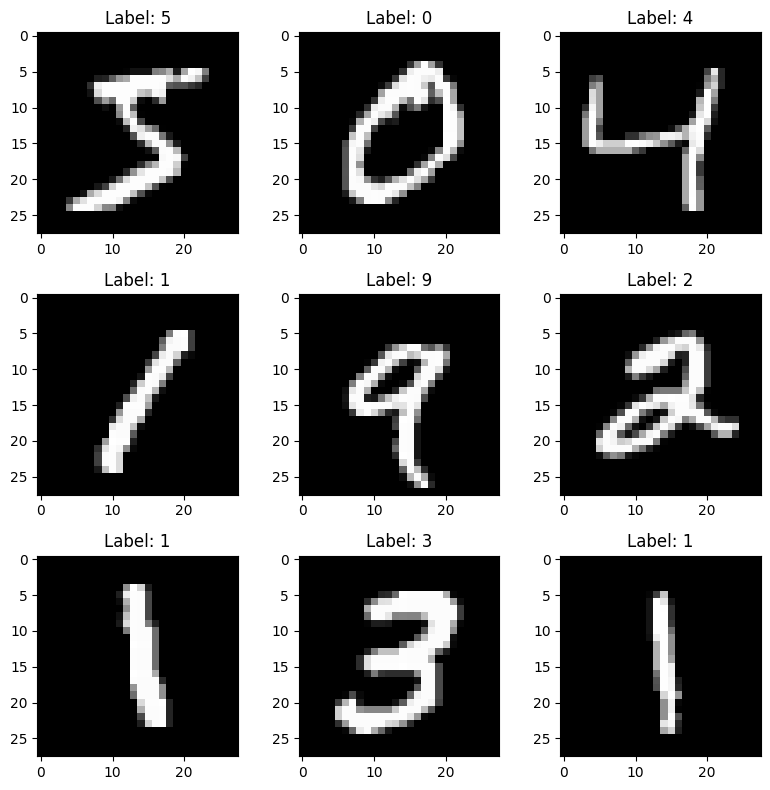

In [22]:
# From Training DataSet
num_images = 9
selected_images = X_train[:num_images]
selected_labels = y_train[:num_images]
# Set up the figure and axis
fig, axes = plt.subplots(3, 3, figsize=(8, 8))
axes = axes.flatten()

# Plot each image
for i, ax in enumerate(axes):
  ax.imshow(selected_images[i], cmap='gray')
  ax.set_title(f"Label: {selected_labels[i]}")
  # ax.axis('off')
plt.tight_layout()
plt.show()


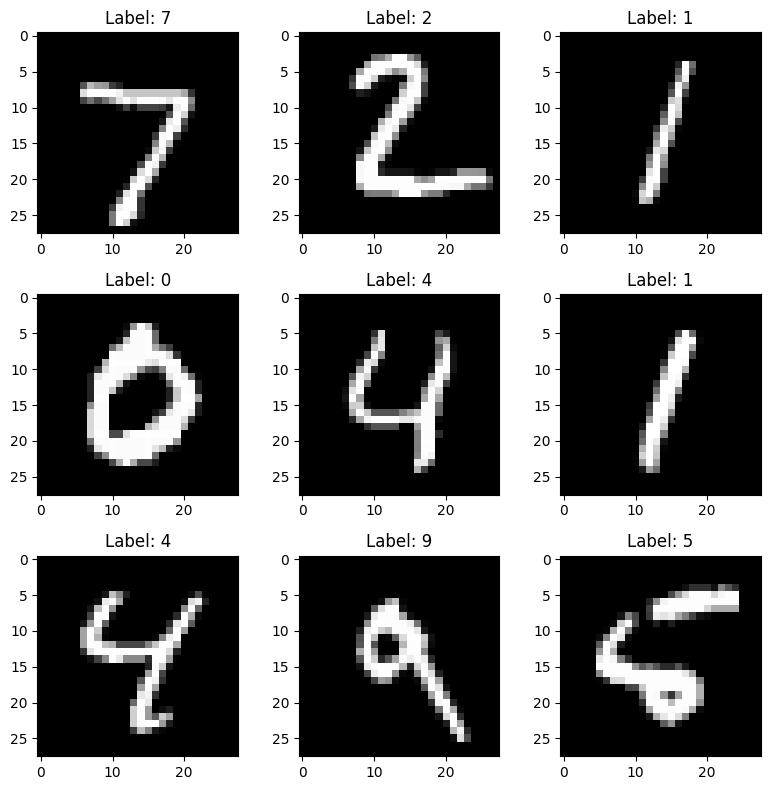

In [23]:
# From Test DataSet
num_images = 9
selected_images = X_test[:num_images]
selected_labels = y_test[:num_images]
# Set up the figure and axis
fig, axes = plt.subplots(3, 3, figsize=(8, 8))
axes = axes.flatten()

# Plot each image
for i, ax in enumerate(axes):
  ax.imshow(selected_images[i], cmap='gray')
  ax.set_title(f"Label: {selected_labels[i]}")
  # ax.axis('off')
plt.tight_layout()
plt.show()


# Building One-Layered Neural Network

In [39]:
def neural_network(activation_function):
  model = Sequential([
      Input(shape=(28, 28)),  # Input layer with 28x28 images
      Flatten(),  # Flatten the 28x28 images into 1D vectors
      Dense(128, activation=activation_function),  # Hidden layer with 128 neurons and ReLU activation
      Dense(10, activation='softmax') # Output layer with 10 neurons (one for each digit) and softmax activation
  ])

  # Compile the model
  model.compile(optimizer='adam',
                loss='SparseCategoricalCrossentropy',
                metrics=['accuracy'])

  # Train the model
  history = model.fit(X_train, y_train, epochs=5, batch_size=32, validation_split=0.2)

  # Evaluate the model
  test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
  print(f'\nTest accuracy: {test_acc}')

  return history, model

# Visualizing the loss

In [43]:
history, model = neural_network("relu")

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8606 - loss: 0.4863 - val_accuracy: 0.9565 - val_loss: 0.1514
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9613 - loss: 0.1350 - val_accuracy: 0.9635 - val_loss: 0.1213
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.9718 - loss: 0.0933 - val_accuracy: 0.9712 - val_loss: 0.1006
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9819 - loss: 0.0617 - val_accuracy: 0.9707 - val_loss: 0.0937
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9861 - loss: 0.0462 - val_accuracy: 0.9729 - val_loss: 0.0900
313/313 - 1s - 2ms/step - accuracy: 0.9741 - loss: 0.0809

Test accuracy: 0.9740999937057495


This model has achieved an accuracy of almost 97% on the dataset using the relu activation function. Let's visualize the loss.

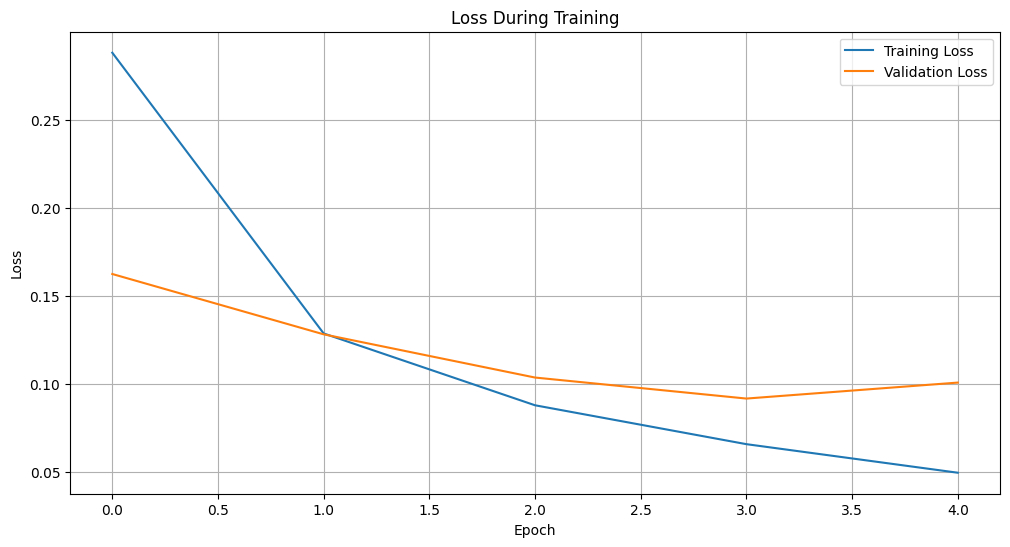

In [38]:
# Extract the loss values
loss_values = history.history['loss']
val_loss_values = history.history['val_loss']

# Plot the loss values
plt.figure(figsize=(12, 6))
plt.plot(loss_values, label='Training Loss')
plt.plot(val_loss_values, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss During Training')
plt.legend()
plt.grid(True)
plt.show()

Let's visualize the Neural Network for the sigmoid activation function.

In [41]:
activation_function = "sigmoid"
history2, model2 = neural_network(activation_function)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.8258 - loss: 0.7176 - val_accuracy: 0.9307 - val_loss: 0.2426
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9312 - loss: 0.2345 - val_accuracy: 0.9482 - val_loss: 0.1869
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9522 - loss: 0.1701 - val_accuracy: 0.9578 - val_loss: 0.1507
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9625 - loss: 0.1301 - val_accuracy: 0.9624 - val_loss: 0.1310
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9694 - loss: 0.1070 - val_accuracy: 0.9641 - val_loss: 0.1197
313/313 - 1s - 2ms/step - accuracy: 0.9659 - loss: 0.1157

Test accuracy: 0.9659000039100647


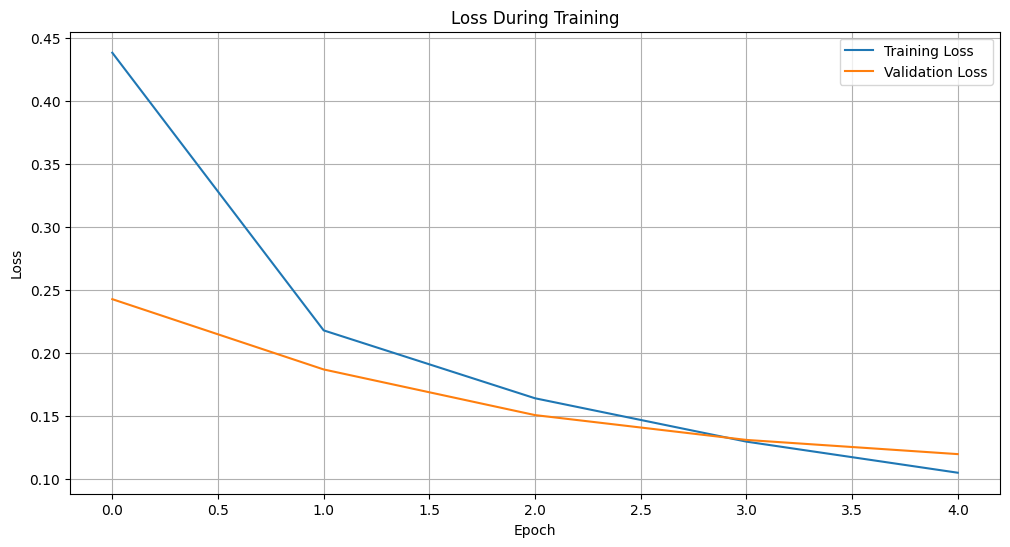

In [42]:
# Extract the loss values
loss_values = history2.history['loss']
val_loss_values = history2.history['val_loss']

# Plot the loss values
plt.figure(figsize=(12, 6))
plt.plot(loss_values, label='Training Loss')
plt.plot(val_loss_values, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss During Training')
plt.legend()
plt.grid(True)
plt.show()

Sigmoid gave an  overall accuracy of 96% which makes relu better for this partcular problem.

# Saving the Model

In [45]:
model.save('my_model.h5')

# Making Prediction

In [53]:
def preprocess_image(image_path):
    # Load the image
    img = image.load_img(image_path, color_mode='grayscale')

    # Convert to numpy array
    img_array = img_to_array(img)

    # Resize the image (MNIST images are 28x28)
    img_array = cv2.resize(img_array, (28, 28))

    # Normalize the image (values between 0 and 1)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)  # Shape becomes (1, 28, 28)
    # Check and correct any possible issues (e.g., invalid pixel values)
    img_array = np.clip(img_array, 0, 1)  # Ensure pixel values are between 0 and 1
    # Apply Gaussian blur (optional)
    img_array = cv2.GaussianBlur(img_array[0], (3, 3), 0)
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension back
    # Final check and ensure image shape matches model input
    if img_array.shape != (1, 28, 28):
        raise ValueError(f"Unexpected image shape: {img_array.shape}. Expected (1, 28, 28).")

    return img_array

In [54]:
class_labels = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
def predict(image_path):

    preprocessed_image = preprocess_image(image_path)
    predictions = model.predict(preprocessed_image)
    # Get the predicted class index
    predicted_class_index = np.argmax(predictions, axis=1)[0]
    # Convert index to class label
    predicted_class_label = class_labels[predicted_class_index]
    return predicted_class_label

In [55]:
predict("/content/sample_data/Capture.PNG")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


'4'